<a href="https://colab.research.google.com/github/gmauricio-toledo/math-ML/blob/main/Notebooks/06-ML-Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>El workflow del Aprendizaje Automático</h1>

Hasta ahora hemos tratado la regresión lineal como un problema puramente algebraico: dados datos $\{x_i\}$ y etiquetas $\{y_i\}$, derivamos una fórmula para los coeficientes $a,b$ del modelo $f_{a,b}$ que minimizan el error cuadrático.

Pero esa derivación esconde una pregunta: ¿cómo sabemos que lo que encontramos es una buena lógica y no un accidente de los datos que nos tocó ver?

En esta notebook formalizamos el protocolo estándar del aprendizaje supervisado. La idea es: separamos los datos en dos conjuntos disjuntos, entrenamos el modelo usando sólo uno de ellos, y evaluamos su desempeño en el otro, que el modelo nunca ha visto.

Esta división nos permite distinguir entre ajustar (memorizar los datos de entrenamiento) y aprender (capturar una regularidad que se manifiesta también en datos nuevos).

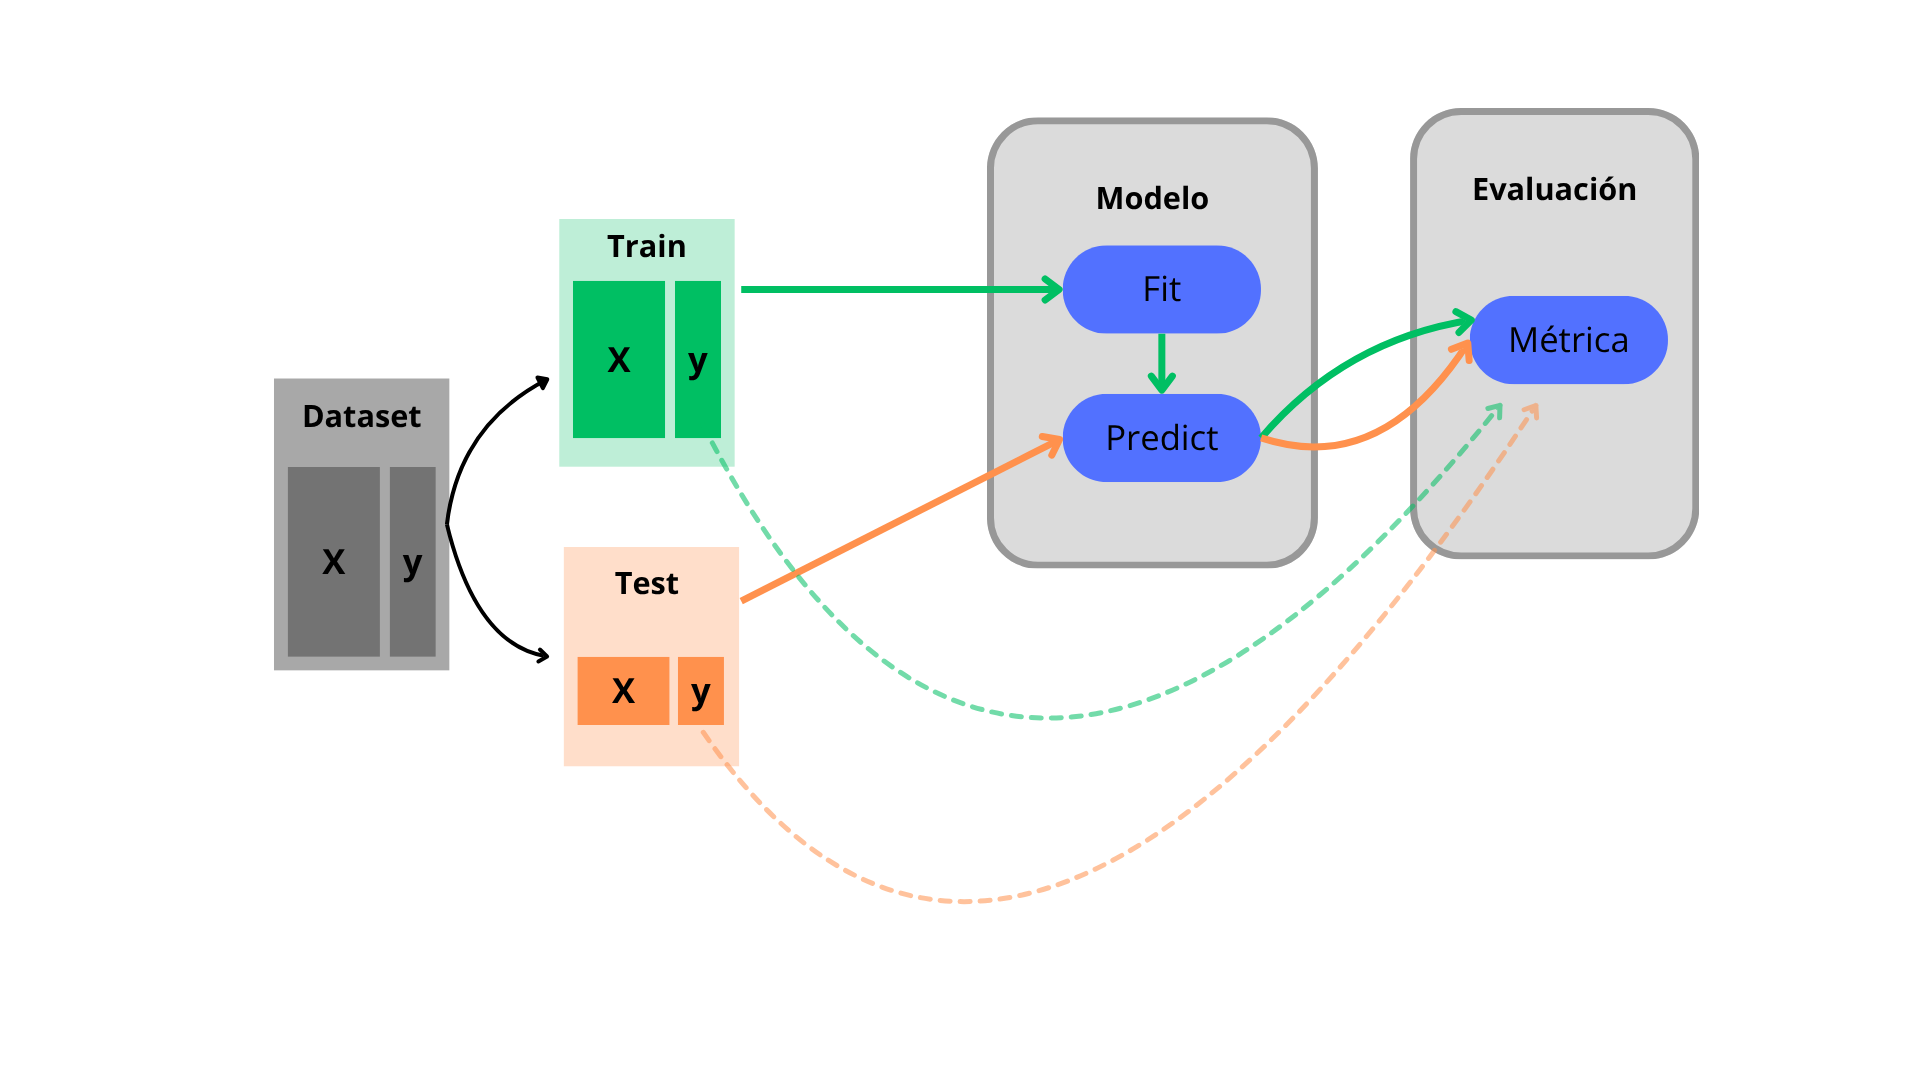

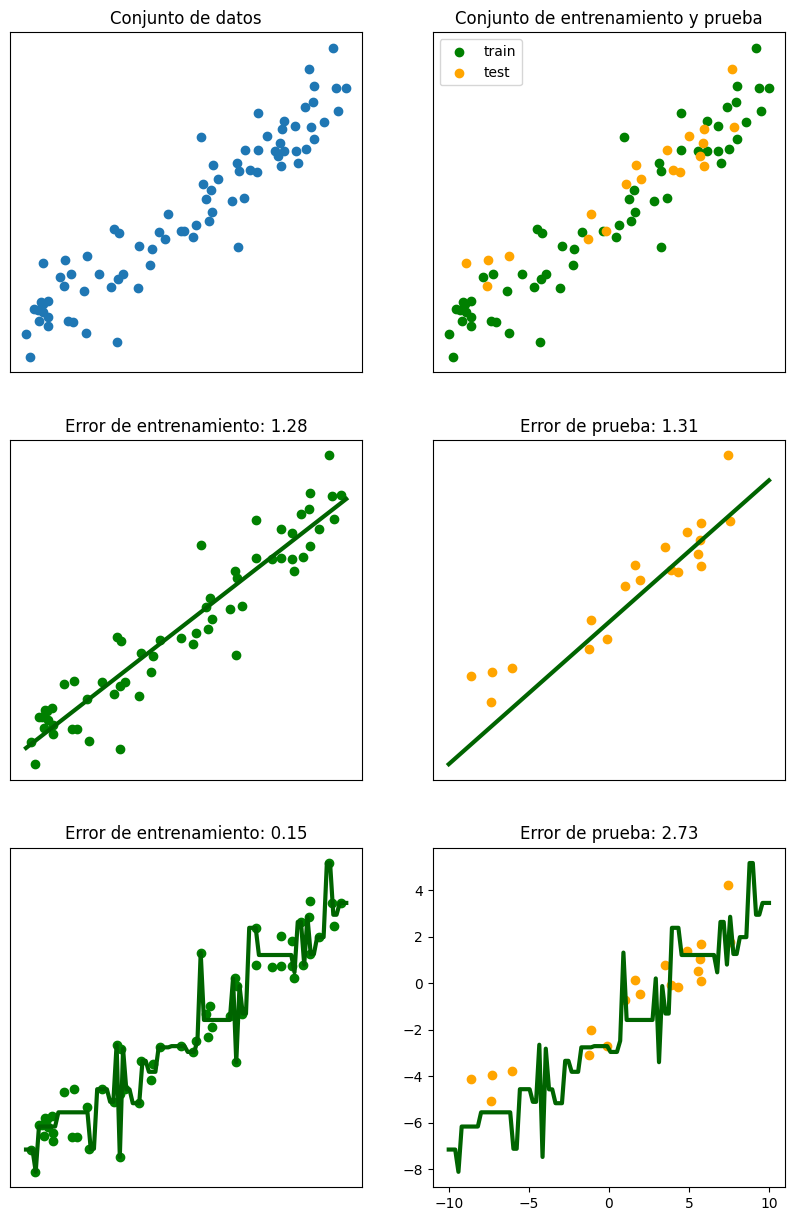

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor

#------------- Conjunto de datos -------------
num_points = 80
np.random.seed(17)
xs = np.random.uniform(-10, 10, num_points)
ys = 0.5*xs - 2 + np.random.normal(0, 1, num_points)

#------------- Separación de datos -------------
x_train, x_test, y_train, y_test = train_test_split(xs, ys, test_size=0.25)

#------------- Entrenamiento y predicción del modelo -------------
model = LinearRegression()
model.fit(x_train.reshape(-1, 1), y_train)
train_error = mean_squared_error(y_train, model.predict(x_train.reshape(-1, 1)))
test_error = mean_squared_error(y_test, model.predict(x_test.reshape(-1, 1)))

model_2 = DecisionTreeRegressor(max_depth=6)
model_2.fit(x_train.reshape(-1, 1), y_train)
train_error_2 = mean_squared_error(y_train, model_2.predict(x_train.reshape(-1, 1)))
test_error_2 = mean_squared_error(y_test, model_2.predict(x_test.reshape(-1, 1)))

#------------- Gráficas -------------
x_axis = np.linspace(-10, 10, 100) # Discretización del eje X
y_axis = model.predict(x_axis.reshape(-1, 1)) # El modelo 1 evaluado en la discretización
y_axis_2 = model_2.predict(x_axis.reshape(-1, 1)) # El modelo 2 evaluado en la discretización

plt.figure(figsize=(10,15))
plt.subplot(3,2,1)
plt.scatter(xs, ys)
plt.title('Conjunto de datos')
plt.xticks([])
plt.yticks([])
plt.subplot(3,2,2)
plt.scatter(x_train, y_train,label='train',c='green')
plt.scatter(x_test, y_test,label='test',c='orange')
plt.legend(loc='best')
plt.title('Conjunto de entrenamiento y prueba')
plt.xticks([])
plt.yticks([])
plt.subplot(3,2,3)
plt.scatter(x_train, y_train,c='green')
plt.plot(x_axis, y_axis,c='darkgreen',linewidth=3)
plt.title(f'Error de entrenamiento: {train_error:.2f}')
plt.xticks([])
plt.yticks([])
plt.subplot(3,2,4)
plt.scatter(x_test, y_test,c='orange')
plt.plot(x_axis, y_axis,c='darkgreen',linewidth=3)
plt.title(f'Error de prueba: {test_error:.2f}')
plt.xticks([])
plt.yticks([])
plt.subplot(3,2,5)
plt.scatter(x_train, y_train,c='green')
plt.plot(x_axis, y_axis_2,c='darkgreen',linewidth=3)
plt.title(f'Error de entrenamiento: {train_error_2:.2f}')
plt.xticks([])
plt.yticks([])
plt.subplot(3,2,6)
plt.scatter(x_test, y_test,c='orange')
plt.plot(x_axis, y_axis_2,c='darkgreen',linewidth=3)
plt.title(f'Error de prueba: {test_error_2:.2f}')
plt.show()

🔵 Algunas cosas que notar:

* ¿Qué efecto tiene la proporción entrenamiento/prueba? ¿Qué pasa si usamos 50/50 en lugar de 75/25? ¿Y 90/10?
* ¿Por qué el error de prueba suele ser más grande?
* Tratamos `test` como si fueran "datos que aún no hemos visto". ¿Qué hipótesis estamos haciendo al tratar una partición aleatoria de los datos como si fuera el futuro? ¿Cuándo podría fallar esa hipótesis?
* Cambia `np.random.seed(17)` por otro valor y vuelve a correr. Los errores cambian. ¿Qué nos dice esto sobre el error de test como *estimador* del verdadero error de prueba? ¿Es una cantidad fija del modelo o una variable aleatoria?


<h3> 🟢 Nunca juzgar un modelo con los datos que usó para aprender.</h3>

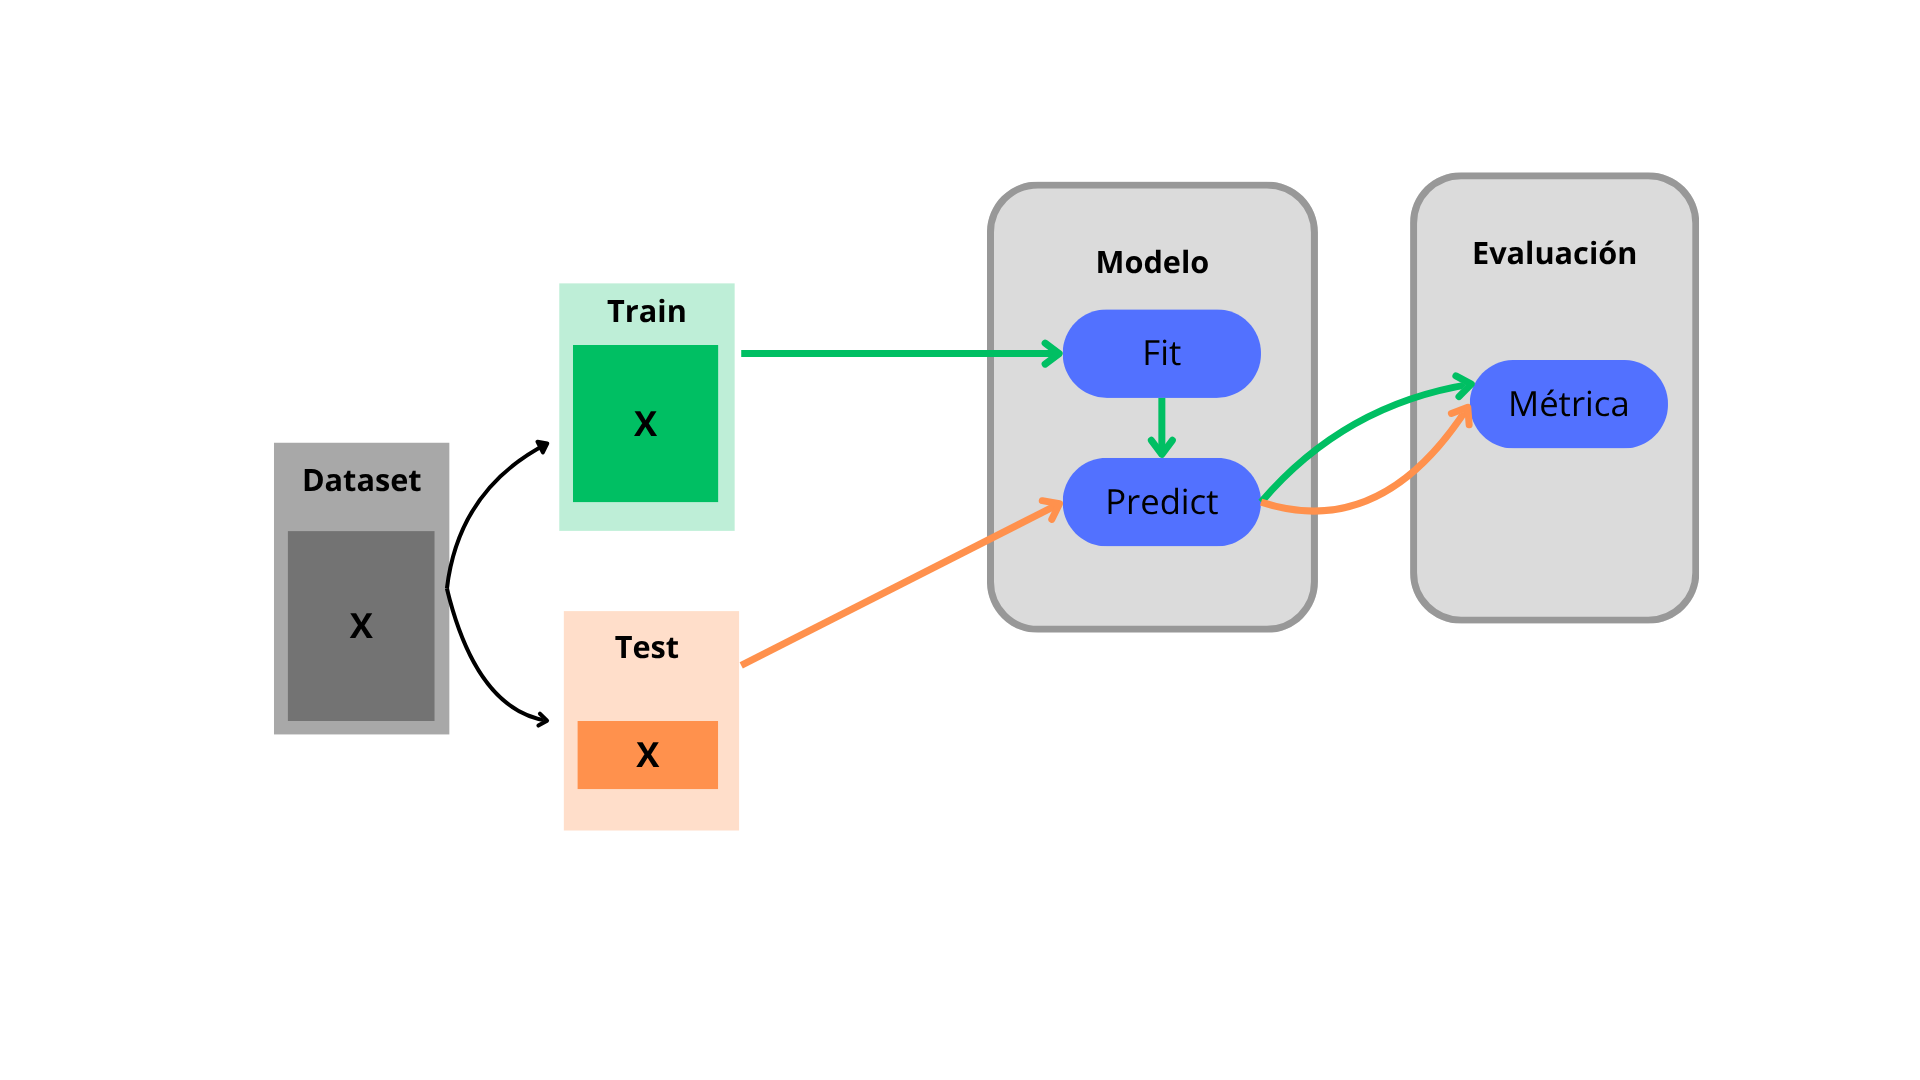